In [1]:
# Force external files to be reloaded
import importlib
# importlib.reload()

(-0.5, 1279.5, 719.5, -0.5)

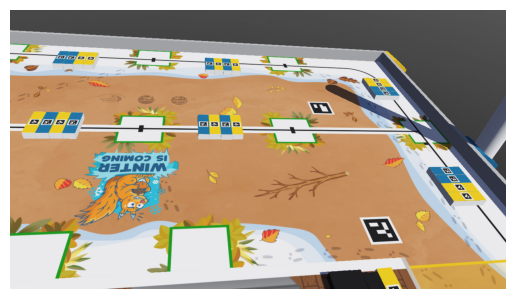

In [2]:
# Fix matplotlib/IPython compatibility issue
import matplotlib
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.get

# load image using opencv
import cv2
import numpy as np
import matplotlib.pyplot as plt

from extrinsic_calibration import (
    show, detect_green_squares, estimate_square_poses, draw_poses
)


# Load an image using OpenCV
image = cv2.imread('../../ressources/watchtower_view.png')

# Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display the image using matplotlib
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')  # Hide the axis

In [3]:
aruco_dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
aruco_parameters =  cv2.aruco.DetectorParameters()
aruco_detector = cv2.aruco.ArucoDetector(aruco_dictionary, aruco_parameters)

markerCorners, markerIds, _ = aruco_detector.detectMarkers(image)

# Filtrer pour ne garder que les tags 20 à 23
allowed_ids = set([20, 21, 22, 23])
filtered_corners = []
filtered_ids = []
for corners, mid in zip(markerCorners, markerIds.flatten() if markerIds is not None else []):
    if mid in allowed_ids:
        filtered_corners.append(corners)
        filtered_ids.append(mid)

markerCorners = tuple(filtered_corners)
markerIds = np.array(filtered_ids, dtype=np.int32).reshape(-1, 1) if filtered_ids else np.empty((0, 1), dtype=np.int32)

print(f"Detected {len(markerIds)} tag(s) in [20..23]")
if len(markerIds):
    print(markerIds.flatten())
    print(markerCorners[0])
# print(markerIds)

Detected 2 tag(s) in [20..23]
[20 22]
[[[1003.  595.]
  [ 937.  598.]
  [ 911.  541.]
  [ 973.  538.]]]


In [4]:
square_size = 0.20  # meters

cameraMatrix = np.array([
    [914.0151876932167, 0.0, 640.0], # k matrix in /camera_info
    [0.0, 914.0151876932167, 360.0],
    [0.0, 0.0, 1.0]
    ])
distCoeffs = np.array([0, 0, 0, 0, 0]) # d matrix in /camera_info

rvec, tvec, markerPoints = cv2.aruco.estimatePoseSingleMarkers(markerCorners, 0.1, cameraMatrix=cameraMatrix, distCoeffs=distCoeffs)

(-0.5, 1279.5, 719.5, -0.5)

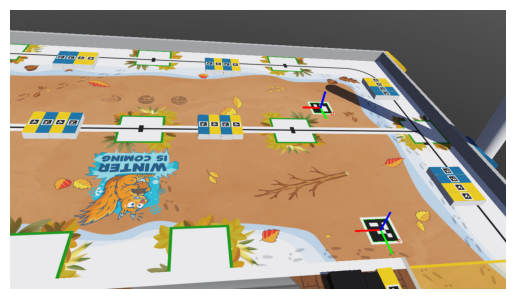

In [5]:
cv2.aruco.drawDetectedMarkers(image, markerCorners)
cv2.drawFrameAxes(image, cameraMatrix, distCoeffs, rvec[0], tvec[0], 0.1) # tag en bas
cv2.drawFrameAxes(image, cameraMatrix, distCoeffs, rvec[1], tvec[1], 0.1) # tag en haut

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')  # Hide the axis

In [6]:
# Detect green squares
squares, squares_cnts = detect_green_squares(image)
print(f"✓ {len(squares)} square(s) detected")

# Estimate pose for each detected square
squares_poses = estimate_square_poses(
    squares=squares,
    square_size=square_size,
    camera_matrix=cameraMatrix,
    dist_coeffs=distCoeffs,
)

✓ 4 square(s) detected



=== Square 0 ===
Position (tvec): [ 0.169087   -0.09638656  1.74026942]
Rotation (rvec): [ 2.27594903 -0.1021277   0.20866176]
Distance: 1.751 m

=== Square 1 ===
Position (tvec): [-0.52736842 -0.09477605  1.59343438]
Rotation (rvec): [ 2.25807645 -0.0937708   0.20883292]
Distance: 1.681 m

=== Square 2 ===
Position (tvec): [ 0.16864301 -0.55263491  2.28204937]
Rotation (rvec): [ 2.25684696 -0.09000211  0.19743692]
Distance: 2.354 m

=== Square 3 ===
Position (tvec): [-0.62435515 -0.54881353  2.11956824]
Rotation (rvec): [ 2.25333805 -0.09496114  0.20278644]
Distance: 2.277 m

✓ 4 pose(s) estimated


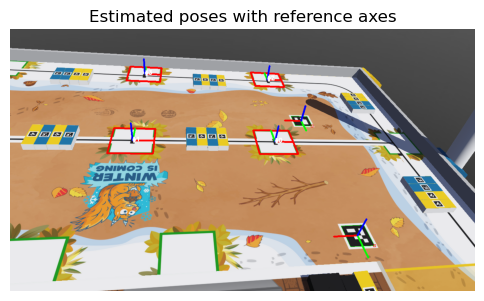


✓ Combiné: 2 markers (ArUco + carrés)
  - aruco_20: tvec=[0.45302074 0.29717028 1.31105338], rvec=[-0.13130392 -3.00273776  1.39081317]
  - aruco_22: tvec=[ 0.34123651 -0.22770092  1.93148798], rvec=[ 0.11705924  2.69074903 -1.26418924]


In [7]:
# Draw squares with centers and orientations
squares_result_img = image.copy()
for sq_cnt in squares_cnts:
    cv2.drawContours(squares_result_img, [sq_cnt], -1, (0, 0, 255), 3)

for pose in squares_poses:
    print(f"\n=== Square {pose['id']} ===")
    print(f"Position (tvec): {pose['tvec'].flatten()}")
    print(f"Rotation (rvec): {pose['rvec'].flatten()}")
    print(f"Distance: {np.linalg.norm(pose['tvec']):.3f} m")

print(f"\n✓ {len(squares_poses)} pose(s) estimated")

# Display reference axes for each detected square
squares_result_img = draw_poses(squares_result_img, squares_poses, cameraMatrix, distCoeffs)
show("Estimated poses with reference axes", squares_result_img)

# Combiner ArUco et carrés avec leurs données de détection
combined_rvecs = []
combined_tvecs = []
combined_ids = []
combined_types = []  # 'aruco' ou 'square'

# ArUco
for i, aruco_id in enumerate(markerIds.flatten()):
    combined_rvecs.append(np.array(rvec[i]).flatten())
    combined_tvecs.append(np.array(tvec[i]).flatten())
    combined_ids.append(f"aruco_{aruco_id}")
    combined_types.append('aruco')

# Carrés
# for square_pose in squares_poses:
#     combined_rvecs.append(np.array(square_pose['rvec']).flatten())
#     combined_tvecs.append(np.array(square_pose['tvec']).flatten())
#     combined_ids.append(f"square_{square_pose['id']}")
#     combined_types.append('square')

print(f"\n✓ Combiné: {len(combined_rvecs)} markers (ArUco + carrés)")
for i, marker_id in enumerate(combined_ids):
    print(f"  - {marker_id}: tvec={combined_tvecs[i]}, rvec={combined_rvecs[i]}")


In [8]:
import tf_transformations as tf_trans
from scipy.spatial.transform import Rotation as R

# Vraies positions (world frame) : dictionnaires par ID
aruco_true_positions_by_id = {
    22: np.array([-0.9, 0.4, 0]),
    20: np.array([-0.9, -0.4, 0]),
}

square_true_positions_by_id = {
    0: np.array([0, -0.2, 0]),
    2: np.array([-0.8, -0.2, 0]),
    1: np.array([0, -0.7, 0]),
    3: np.array([-0.9, -0.7, 0]),
}

# Orientations
aruco_orientation_quat = tf_trans.quaternion_from_euler(0, 0, 0)
rotation_180_z = tf_trans.quaternion_from_euler(0, 0, np.pi)
square_orientation_quat = tf_trans.quaternion_multiply(aruco_orientation_quat, rotation_180_z)
marker_orientations = {
    'aruco': aruco_orientation_quat,
    'square': square_orientation_quat,
}

# Construire la liste des markers "vrais"
true_markers = []
for aruco_id, pos in aruco_true_positions_by_id.items():
    true_markers.append({
        'name': f'aruco_{aruco_id}',
        'type': 'aruco',
        'pos': pos,
        'orientation': marker_orientations['aruco'],
    })
# for square_id, pos in square_true_positions_by_id.items():
#     true_markers.append({
#         'name': f'square_{square_id}',
#         'type': 'square',
#         'pos': pos,
#         'orientation': marker_orientations['square'],
#     })

# Position/orientation vraie de la caméra (simu)
camera_support_in_world_pos = np.array([-0.225, 1.12, 0.08])
camera_support_in_world_quat = np.array([0, 0, -0.707105, 0.707105])
camera_in_support_pos = np.array([0, 0, 0.91])
camera_in_support_quat = np.array([-0.031363, 0.34146, -0.0859194, 0.935435])

T_world_support = tf_trans.concatenate_matrices(
    tf_trans.translation_matrix(camera_support_in_world_pos),
    tf_trans.quaternion_matrix(camera_support_in_world_quat)
)
T_support_camera = tf_trans.concatenate_matrices(
    tf_trans.translation_matrix(camera_in_support_pos),
    tf_trans.quaternion_matrix(camera_in_support_quat)
)
T_world_camera_true = T_world_support @ T_support_camera

camera_pos_in_world = tf_trans.translation_from_matrix(T_world_camera_true)
camera_quat_in_world = tf_trans.quaternion_from_matrix(T_world_camera_true)
camera_euler_in_world = tf_trans.euler_from_quaternion(camera_quat_in_world)

print("=== VRAIE POSITION CAMÉRA (simulation) ===")
print(f"Position: {camera_pos_in_world}")
print(f"Quaternion (xyzw): {camera_quat_in_world}")
print(f"Euler (RPY rad): {camera_euler_in_world}")
print(f"Euler (RPY deg): {np.rad2deg(camera_euler_in_world)}")
print(f"\n✓ Orientation des carrés: rotation de 180° autour de Z")
print(f"✓ Markers détectés: {combined_ids}")

# ---- Appariement robustes : associer chaque détection à la position vraie la plus proche (distance pattern) ----
detected_positions = [np.array(t).flatten() for t in combined_tvecs]
true_positions = [tm['pos'] for tm in true_markers]

nd = len(detected_positions)
nt = len(true_positions)

if nd == 0 or nt == 0:
    matched_assignments = []
else:
    # Matrices de distances invariantes à la translation/rotation (distances inter-points)
    det_dist = np.zeros((nd, nd))
    for i in range(nd):
        for j in range(nd):
            det_dist[i, j] = np.linalg.norm(detected_positions[i] - detected_positions[j])

    true_dist = np.zeros((nt, nt))
    for i in range(nt):
        for j in range(nt):
            true_dist[i, j] = np.linalg.norm(true_positions[i] - true_positions[j])

    # Score de similarité entre un détecté i et un vrai k: comparer leur signature de distances triées
    def signature_cost(i_det, k_true):
        sig_det = np.sort(det_dist[i_det])
        sig_true = np.sort(true_dist[k_true])
        m = min(len(sig_det), len(sig_true))
        return np.linalg.norm(sig_det[:m] - sig_true[:m])

    # Calcul des coûts
    cost_matrix = np.zeros((nd, nt))
    for i in range(nd):
        for k in range(nt):
            cost_matrix[i, k] = signature_cost(i, k)

    # Appariement glouton : prendre à chaque fois le couple de coût minimal non encore utilisé
    matched_assignments = []
    used_det = set()
    used_true = set()
    while len(used_det) < nd and len(used_true) < nt:
        min_cost = None
        min_pair = None
        for i in range(nd):
            if i in used_det:
                continue
            for k in range(nt):
                if k in used_true:
                    continue
                c = cost_matrix[i, k]
                if (min_cost is None) or (c < min_cost):
                    min_cost = c
                    min_pair = (i, k)
        if min_pair is None:
            break
        i, k = min_pair
        used_det.add(i)
        used_true.add(k)
        matched_assignments.append({
            'det_index': i,
            'true_index': k,
            'true_name': true_markers[k]['name'],
            'true_type': true_markers[k]['type'],
            'true_pos': true_markers[k]['pos'],
            'true_orientation': true_markers[k]['orientation'],
            'cost': min_cost,
        })

print("\n=== Appariements détectés -> positions vraies ===")
for m in matched_assignments:
    print(f"det {m['det_index']} ({combined_ids[m['det_index']]}) -> {m['true_name']} | coût={m['cost']:.4f}")
    print(f"    true position: {m['true_pos'][:2]}, detected position: {combined_tvecs[m['det_index']][:2]}")


=== VRAIE POSITION CAMÉRA (simulation) ===
Position: [-0.225  1.12   0.99 ]
Quaternion (xyzw): (0.21927176258168785, 0.26362575691152335, -0.7222068562693683, 0.6006984361430138)
Euler (RPY rad): (-0.15224587741485085, 0.685988609765597, -1.8084419258870796)
Euler (RPY deg): [  -8.72304622   39.30425213 -103.61608985]

✓ Orientation des carrés: rotation de 180° autour de Z
✓ Markers détectés: ['aruco_20', 'aruco_22']

=== Appariements détectés -> positions vraies ===
det 0 (aruco_20) -> aruco_22 | coût=0.0203
    true position: [-0.9  0.4], detected position: [0.45302074 0.29717028]
det 1 (aruco_22) -> aruco_20 | coût=0.0203
    true position: [-0.9 -0.4], detected position: [ 0.34123651 -0.22770092]


In [9]:
camera_estimates = []

# Utiliser les appariements calculés dans la cellule précédente
for match in matched_assignments:
    idx = match['det_index']
    marker_id = combined_ids[idx]
    true_name = match['true_name']
    true_pos = match['true_pos']
    marker_orientation = match['true_orientation']
    
    print(f"\n=== {marker_id} -> {true_name} ===")
    
    # 1. Transformation camera -> marker (mesurée par OpenCV)
    rvec_flat = np.array(combined_rvecs[idx]).flatten()
    tvec_flat = np.array(combined_tvecs[idx]).flatten()
    rot_mat_cv, _ = cv2.Rodrigues(rvec_flat)

    # 2. Matrice camera -> marker
    T_cam_marker_cv = np.eye(4)
    T_cam_marker_cv[:3, :3] = rot_mat_cv
    T_cam_marker_cv[:3, 3] = tvec_flat
    print(f"T_camera_{marker_id} (OpenCV):\n{T_cam_marker_cv}")

    # 3. OpenCV -> ROS optical (identique ici)
    T_cam_marker_ros = T_cam_marker_cv.copy()

    # 4. Inverser pour marker -> camera
    T_marker_cam = np.linalg.inv(T_cam_marker_ros)

    # 5. Transformation world -> marker (position vraie) avec orientation adaptée
    T_world_marker = np.eye(4)
    T_world_marker[:3, 3] = true_pos
    T_world_marker[:3, :3] = tf_trans.quaternion_matrix(marker_orientation)[:3, :3]
    print(f"T_world_{true_name}:\n{T_world_marker}")

    # 6. world -> camera
    T_world_cam = T_world_marker @ T_marker_cam

    cam_pos = T_world_cam[:3, 3]
    cam_quat = tf_trans.quaternion_from_matrix(T_world_cam)
    cam_euler = tf_trans.euler_from_quaternion(cam_quat)

    camera_estimates.append({
        'det_id': marker_id,
        'true_name': true_name,
        'position': cam_pos,
        'quaternion': cam_quat,
        'euler': cam_euler,
        'transform_matrix': T_world_cam,
        'match_cost': match['cost'],
    })

    print(f"Camera position (world frame): {cam_pos}")
    print(f"Camera quaternion (xyzw): {cam_quat}")
    print(f"Camera orientation (RPY rad): {cam_euler}")
    print(f"Camera orientation (RPY deg): {np.rad2deg(cam_euler)}")
    print(f"Match cost: {match['cost']:.4f}")

# Moyenne des estimations
print("\n=== CALIBRATION EXTRINSÈQUE (moyenne de tous les markers appariés) ===")
if len(camera_estimates) > 0:
    avg_pos = np.mean([est['position'] for est in camera_estimates], axis=0)
    avg_quat = np.mean([est['quaternion'] for est in camera_estimates], axis=0)
    avg_quat = avg_quat / np.linalg.norm(avg_quat)
    avg_euler = tf_trans.euler_from_quaternion(avg_quat)

    print(f"Camera position moyenne: {avg_pos}")
    print(f"Camera quaternion moyen (xyzw): {avg_quat}")
    print(f"Camera orientation moyenne (RPY rad): {avg_euler}")
    print(f"Camera orientation moyenne (RPY deg): {np.rad2deg(avg_euler)}")

    print("=== VRAIE POSITION CAMÉRA (simulation) ===")
    print(f"Position: {camera_pos_in_world}")
    print(f"Quaternion (xyzw): {camera_quat_in_world}")
    print(f"Euler (RPY rad): {camera_euler_in_world}")
    print(f"Euler (RPY deg): {np.rad2deg(camera_euler_in_world)}")

    distance_error = np.linalg.norm(avg_pos - camera_pos_in_world)
    dot_product = np.clip(np.dot(avg_quat, camera_quat_in_world), -1.0, 1.0)
    angle_error_rad = 2 * np.arccos(dot_product)
    angle_error_deg = np.degrees(angle_error_rad)
    print(f"\nErreur de position (distance): {distance_error} m")
    print(f"Erreur d'orientation: {angle_error_rad} rad ({angle_error_deg} deg)")
else:
    print("⚠ Aucune estimation de caméra disponible !")

# # Commande ROS2 pour static_transform_publisher
# if len(camera_estimates) > 0:
#     print(f"\n# Commande ROS2:")
#     print(f"ros2 run tf2_ros static_transform_publisher {avg_pos[0]:.6f} {avg_pos[1]:.6f} {avg_pos[2]:.6f} " +
#           f"{avg_quat[0]:.6f} {avg_quat[1]:.6f} {avg_quat[2]:.6f} {avg_quat[3]:.6f} world camera_optical_frame")



=== aruco_20 -> aruco_22 ===
T_camera_aruco_20 (OpenCV):
[[-9.82428140e-01  1.42511232e-01  1.20521774e-01  4.53020735e-01]
 [ 2.39021012e-04  6.46700483e-01 -7.62744012e-01  2.97170278e-01]
 [-1.86641078e-01 -7.49312374e-01 -6.35370816e-01  1.31105338e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
T_world_aruco_22:
[[ 1.   0.   0.  -0.9]
 [ 0.   1.   0.   0.4]
 [ 0.   0.   1.   0. ]
 [ 0.   0.   0.   1. ]]
Camera position (world frame): [-0.2103143   1.12564782  1.00507104]
Camera quaternion (xyzw): (-0.039503774245513046, -0.9033962916436941, 0.4184366265108024, 0.08500224502353042)
Camera orientation (RPY rad): (-2.2653417608452413, -0.12081547076370355, 2.9975372629499106)
Camera orientation (RPY deg): [-129.79452205   -6.92221657  171.7462341 ]
Match cost: 0.0203

=== aruco_22 -> aruco_20 ===
T_camera_aruco_22 (OpenCV):
[[-9.83119394e-01  1.41035462e-01  1.16555802e-01  3.41236509e-01]
 [ 3.12243450e-04  6.38330515e-01 -7.69762338e-01 -2.27700924e-01]
 [